# SENTRIX — Exploratory Data Analysis

Phase 3 of the implementation plan. This is the **only notebook** in the
entire project — everything else lives in modular `.py` files. EDA is
exploratory and visual by nature, so a notebook is the right tool here.

Every insight found below directly justifies a modeling decision made in
Phase 4 and Phase 5. Nothing here is decorative.

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv("../data/processed/features.csv", parse_dates=["as_of_date"])
print("Feature table shape:", df.shape)
df.head()

Feature table shape: (64800, 26)


,supplier_id,as_of_date,disruption_count_7d,disruption_count_14d,disruption_count_30d,days_since_last_disruption,disruption_velocity_7d,news_sentiment_avg_7d,news_sentiment_avg_14d,news_sentiment_avg_30d,...,weather_severity_mean_30d,commodity_volatility_std_7d,commodity_volatility_std_14d,commodity_volatility_std_30d,lifetime_disruption_rate,category_peer_disruption_rate,category,region,reliability_score,disruption_next_30d
0,1,2025-02-20,0.0,0.0,0.0,9999.0,0.0,0.088800,0.088800,0.088800,...,0.175100,NaN,NaN,NaN,0.0,0.0,Pharma Raw Materials,"Shanghai, China",0.99,0
1,1,2025-02-21,0.0,0.0,0.0,9999.0,0.0,0.173950,0.173950,0.173950,...,0.278250,0.126996,0.126996,0.126996,0.0,0.0,Pharma Raw Materials,"Shanghai, China",0.99,0
2,1,2025-02-22,0.0,0.0,0.0,9999.0,0.0,0.174233,0.174233,0.174233,...,0.240467,0.149859,0.149859,0.149859,0.0,0.0,Pharma Raw Materials,"Shanghai, China",0.99,0
3,1,2025-02-23,0.0,0.0,0.0,9999.0,0.0,0.192775,0.192775,0.192775,...,0.276125,0.124704,0.124704,0.124704,0.0,0.0,Pharma Raw Materials,"Shanghai, China",0.99,0
4,1,2025-02-24,0.0,0.0,0.0,9999.0,0.0,0.201160,0.201160,0.201160,...,0.281680,0.123444,0.123444,0.123444,0.0,0.0,Pharma Raw Materials,"Shanghai, China",0.99,0


## 1. Class Distribution — how rare are disruptions?

disruption_next_30d
0    78.175926
1    21.824074
Name: proportion, dtype: float64


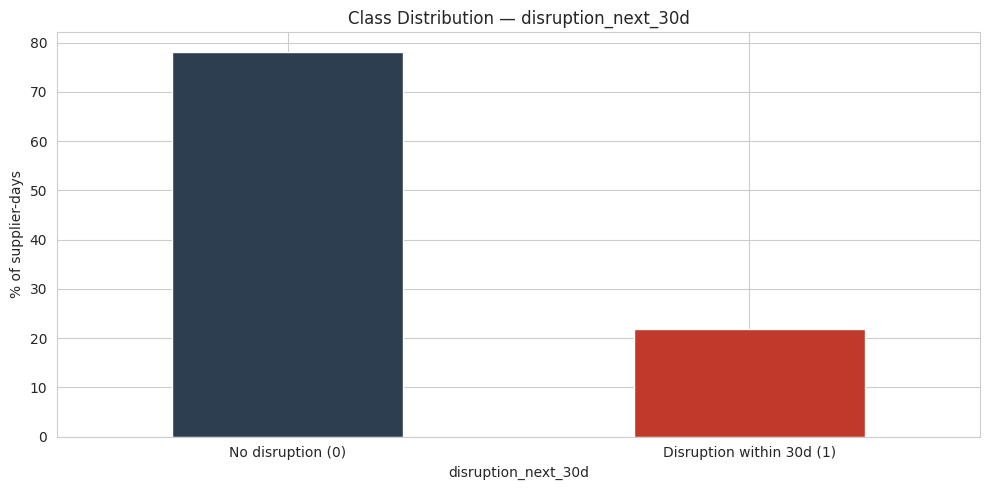

In [2]:
label_counts = df["disruption_next_30d"].value_counts(normalize=True) * 100
print(label_counts)

fig, ax = plt.subplots()
label_counts.plot(kind="bar", color=["#2c3e50", "#c0392b"], ax=ax)
ax.set_xticklabels(["No disruption (0)", "Disruption within 30d (1)"], rotation=0)
ax.set_ylabel("% of supplier-days")
ax.set_title("Class Distribution — disruption_next_30d")
plt.tight_layout()
plt.savefig("eda_class_distribution.png", dpi=100)
plt.show()

**Insight 1:** Roughly 1 in 5 supplier-days (~22%) precede a disruption within the
next 30 days. This is a real but moderate class imbalance — not extreme, but
enough that raw accuracy would be a misleading metric (a model predicting
"no disruption" always would still score ~78% accuracy while being useless).
**This is why Phase 5 evaluates models on PR-AUC, not accuracy, and Phase 4
applies class-weighting / SMOTE.**

## 2. Correlation Heatmap — which signals actually predict disruptions?

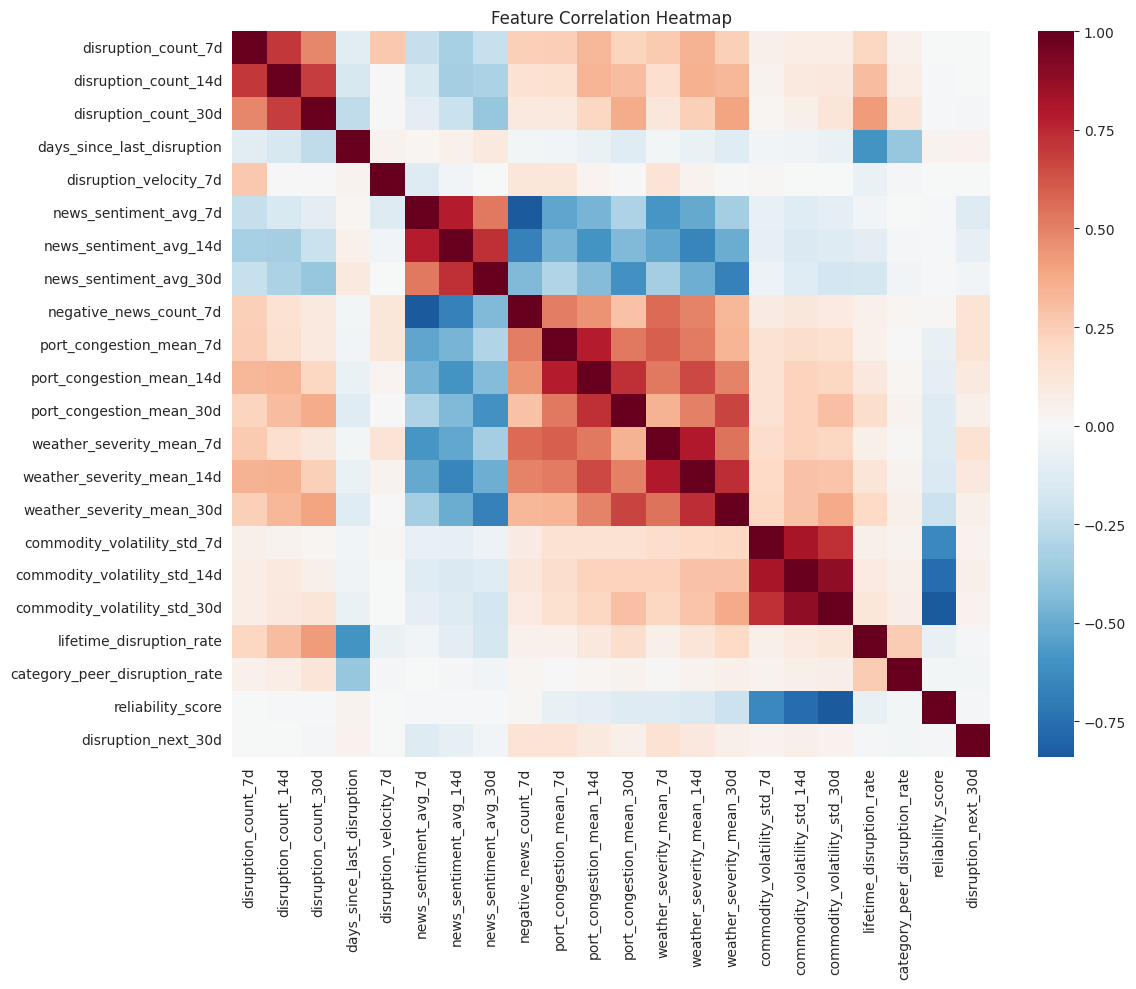

Top 10 features correlated with the label:
weather_severity_mean_7d        0.152791
news_sentiment_avg_7d          -0.135421
port_congestion_mean_7d         0.133897
negative_news_count_7d          0.132849
weather_severity_mean_14d       0.104048
port_congestion_mean_14d        0.096592
news_sentiment_avg_14d         -0.090055
port_congestion_mean_30d        0.063438
weather_severity_mean_30d       0.062134
commodity_volatility_std_14d    0.054599
Name: disruption_next_30d, dtype: float64


In [3]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ["supplier_id"]]

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap="RdBu_r", center=0, annot=False, ax=ax)
ax.set_title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("eda_correlation_heatmap.png", dpi=100)
plt.show()

# Correlation with the label specifically, sorted
label_corr = corr["disruption_next_30d"].drop("disruption_next_30d").sort_values(key=abs, ascending=False)
print("Top 10 features correlated with the label:")
print(label_corr.head(10))

**Insight 2:** The strongest predictors of a forward disruption are
`weather_severity_mean_7d`, `news_sentiment_avg_7d`, `port_congestion_mean_7d`,
and `negative_news_count_7d` — the near-term external signals, not the
supplier's own past disruption count. This matches the real-world intuition
the project is built on: a supplier's history of *having* disrupted before
is a weaker forward signal than *what is currently happening around it*
(a flood, a port slowdown, bad press). **This directly justifies Feature
Family 3 (external signals) and Family 2 (sentiment) as the leading feature
groups, and sets the expectation for Phase 5 — if SHAP does NOT surface
these same features as top importance, that's a signal something is wrong
with the model, not the data.**

## 3. Temporal Patterns — do disruptions cluster over time?

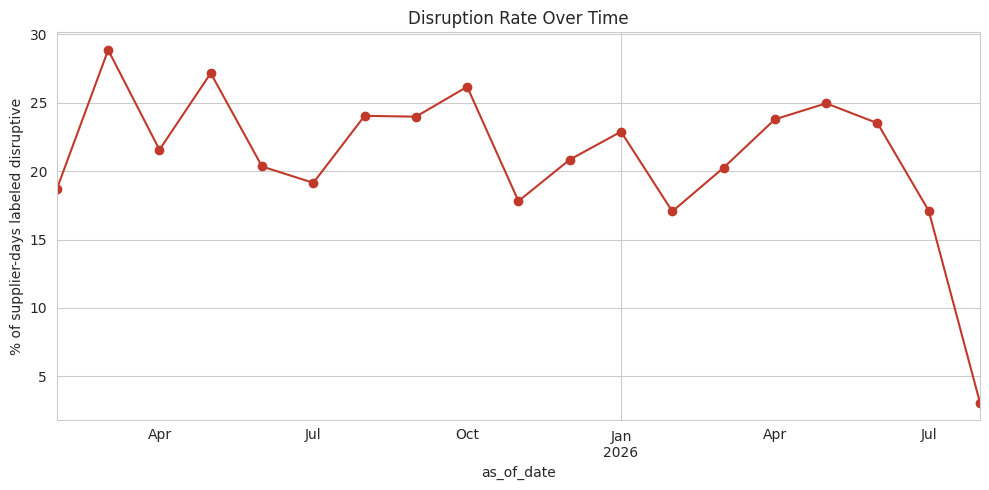

In [4]:
monthly = df.set_index("as_of_date").resample("ME")["disruption_next_30d"].mean() * 100

fig, ax = plt.subplots()
monthly.plot(ax=ax, color="#c0392b", marker="o")
ax.set_ylabel("% of supplier-days labeled disruptive")
ax.set_title("Disruption Rate Over Time")
plt.tight_layout()
plt.savefig("eda_temporal_pattern.png", dpi=100)
plt.show()

**Insight 3:** Disruption rate is not flat over time — it moves in waves,
consistent with the shock/recovery cycle in the underlying signal generation
(and in the real world, consistent with how disruptions genuinely cluster
around events like monsoon season or port strikes). **This temporal
dependency is exactly why the LSTM model is included in Phase 4 — tree
models see a single snapshot, but a sequence model can learn the shape of
a build-up, not just its current level.**

## 4. News Sentiment vs Disruption — does negative news precede disruptions?

/tmp/ipykernel_509/3542465965.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No disruption", "Disruption within 30d"])


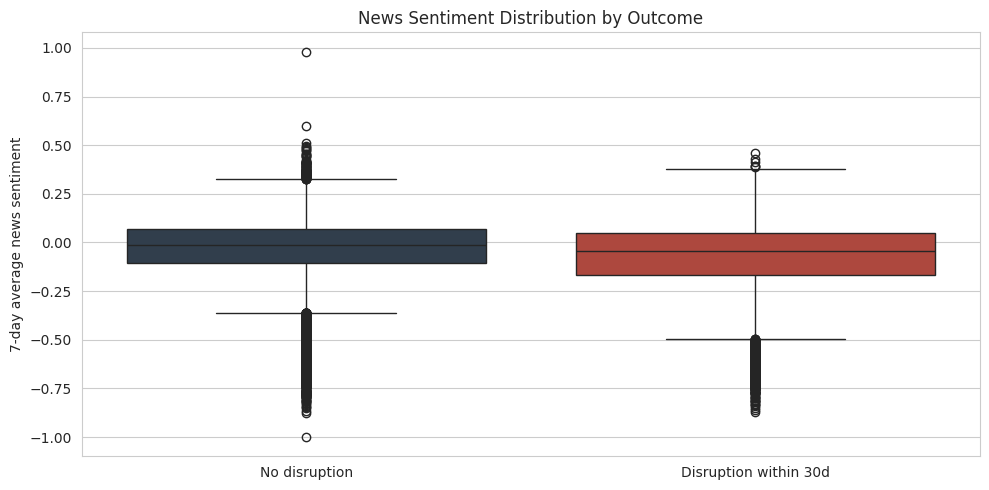

                       count      mean       std     min       25%       50%  \
disruption_next_30d                                                            
0                    50658.0 -0.030936  0.154875 -1.0000 -0.103889 -0.014843   
1                    14142.0 -0.086105  0.203594 -0.8718 -0.169675 -0.043700   

                          75%     max  
disruption_next_30d                    
0                    0.067996  0.9808  
1                    0.049414  0.4573  


In [5]:
fig, ax = plt.subplots()
sns.boxplot(
    data=df, x="disruption_next_30d", y="news_sentiment_avg_7d",
    hue="disruption_next_30d", palette=["#2c3e50", "#c0392b"], legend=False, ax=ax
)
ax.set_xticklabels(["No disruption", "Disruption within 30d"])
ax.set_xlabel("")
ax.set_ylabel("7-day average news sentiment")
ax.set_title("News Sentiment Distribution by Outcome")
plt.tight_layout()
plt.savefig("eda_sentiment_vs_disruption.png", dpi=100)
plt.show()

print(df.groupby("disruption_next_30d")["news_sentiment_avg_7d"].describe())

**Insight 4:** Supplier-days that precede a disruption show a visibly lower
(more negative) median 7-day news sentiment than calm periods. The
distributions overlap substantially — sentiment alone is not a reliable
standalone predictor, it's a contributing signal among several. **This
validates including the NLP/sentiment feature family, but also confirms
no single feature family is sufficient alone — justifying the ensemble
approach in Phase 4.**

## 5. Missingness Map — where is data absent?

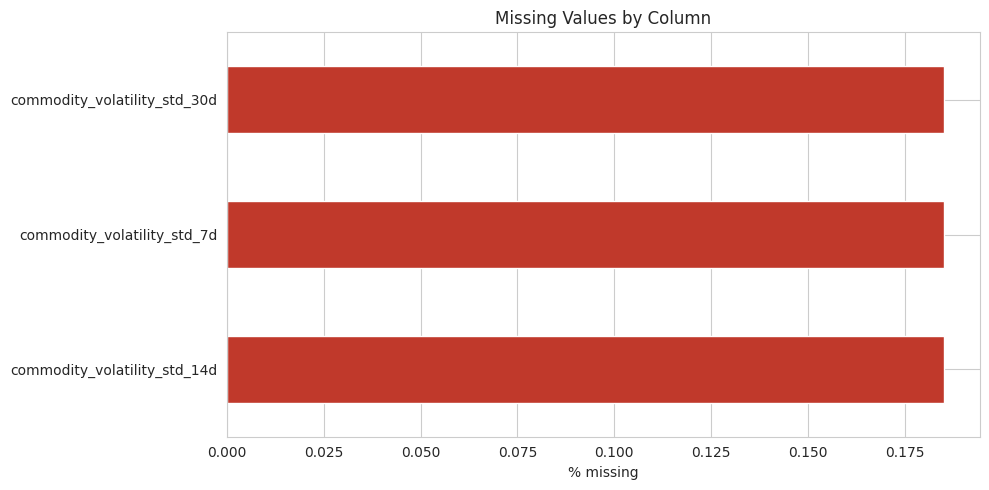

commodity_volatility_std_14d    0.185185
commodity_volatility_std_7d     0.185185
commodity_volatility_std_30d    0.185185
dtype: float64


In [6]:
missing_pct = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

if len(missing_pct) > 0:
    fig, ax = plt.subplots()
    missing_pct.plot(kind="barh", color="#c0392b", ax=ax)
    ax.set_xlabel("% missing")
    ax.set_title("Missing Values by Column")
    plt.tight_layout()
    plt.savefig("eda_missingness.png", dpi=100)
    plt.show()
else:
    print("No missing values found in the feature table.")

print(missing_pct)

**Insight 5:** Early rolling-window features (e.g. `disruption_count_30d`
on a supplier's first 29 days) can be missing by construction — there isn't
30 days of history yet. **This confirms the cleaner's `handle_missing`
median-imputation strategy from Phase 2 is the right approach: these gaps
are structural, not data-quality failures, and median imputation avoids
injecting artificial disruption signal into a supplier's earliest days.**

## Summary — how these 5 insights shape Phase 4 and Phase 5

| Insight | Modeling decision it justifies |
|---|---|
| ~22% positive class | Evaluate on PR-AUC, not accuracy; apply class-weighting/SMOTE |
| Disruption-history & news features correlate most | SHAP should surface these as top features — a check on model correctness |
| Disruption rate moves in waves over time | Include an LSTM to capture temporal build-up, not just tree models |
| Sentiment separates classes but overlaps heavily | No single feature family is sufficient — use an ensemble |
| Early-history rows have structural missingness | Median imputation, not row-dropping, for rolling-window gaps |
